In [142]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import matplotlib

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [143]:
# from google.colab import drive
# drive.mount('/content/drive/') #/Colab_notebooks/Python_Files
df = pd.read_csv('/content/ottdata.csv')

In [144]:
df.shape

(1000, 8)

In [145]:
# let's check the first 5 rows of the data
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [146]:
# let's check column types and number of values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


- There are 5 numeric (float and int type) and 3 string (object type) columns in the data.
- The target variable is the views_content (first day views), which is a float type.

In [147]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
visitors,1000.0,NaN,NaN,NaN,1.70429,0.231973,1.25,1.55,1.7,1.83,2.34
ad_impressions,1000.0,NaN,NaN,NaN,1434.71229,289.534834,1010.87,1210.33,1383.58,1623.67,2424.2
major_sports_event,1000.0,NaN,NaN,NaN,0.4,0.490143,0.0,0.0,0.0,1.0,1.0
genre,1000,8,Others,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dayofweek,1000,7,Friday,369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,1000,4,Winter,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
views_trailer,1000.0,NaN,NaN,NaN,66.91559,35.00108,30.08,50.9475,53.96,57.755,199.92
views_content,1000.0,NaN,NaN,NaN,0.4734,0.105914,0.22,0.4,0.45,0.52,0.89


- There are 8 unique genres.
- In total 4 seasons observed.
- Views trailer & ad impressions seems to have outliers.
- The mean views content has mean of 0.47 with standard deviation of 0.1
- Mean is almost similar or very low differnce to median for views content.



**Checking duplicate values**

In [148]:
df.duplicated().sum()

0

- There are no duplicates.

**Checking missing values**

In [149]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


##Exploratory Data Analysis (EDA)

###Univariate Analysis

In [150]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=True, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [151]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=45, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

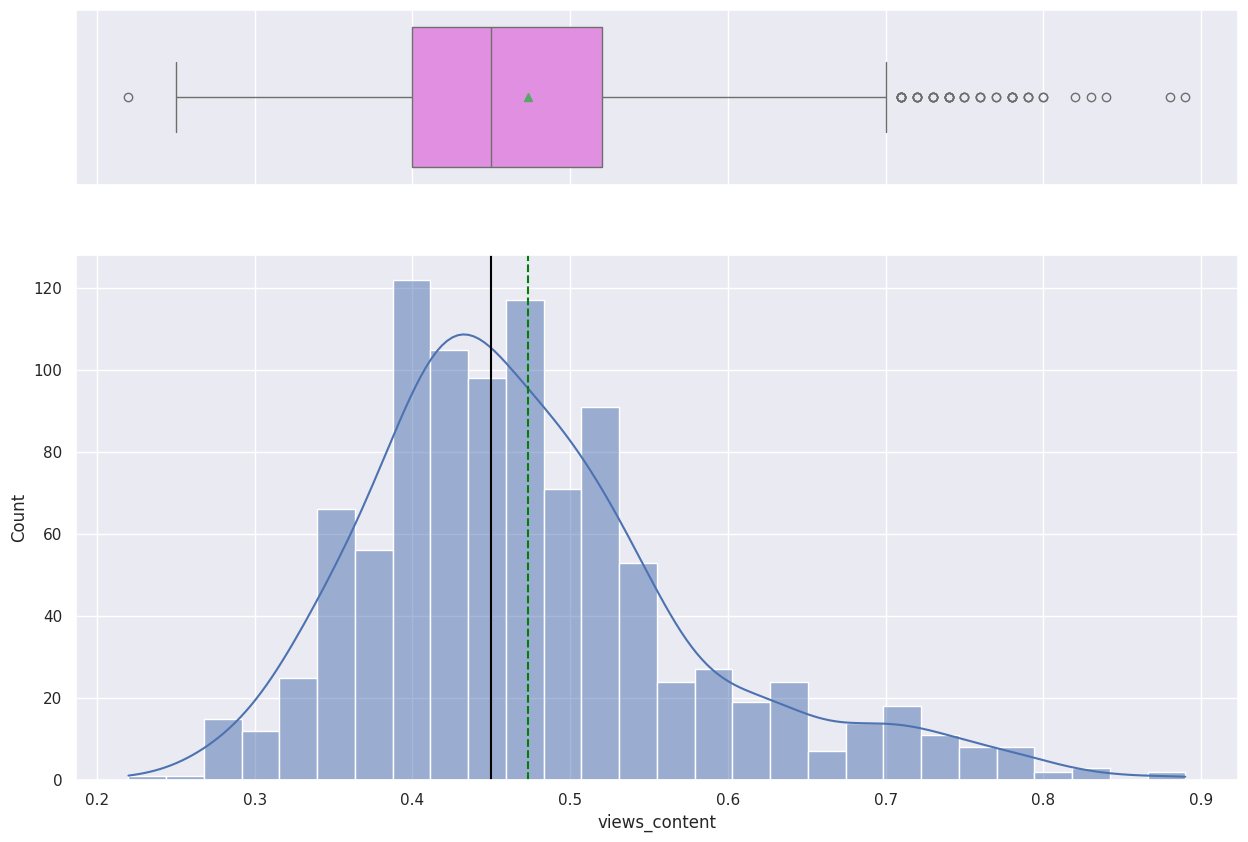

In [152]:
# views content histplot
histogram_boxplot(df, "views_content")

- Few outliers can be observed in the views content field and distribution is right skewed.
- Avg less than 0.5 million watched the actual content.

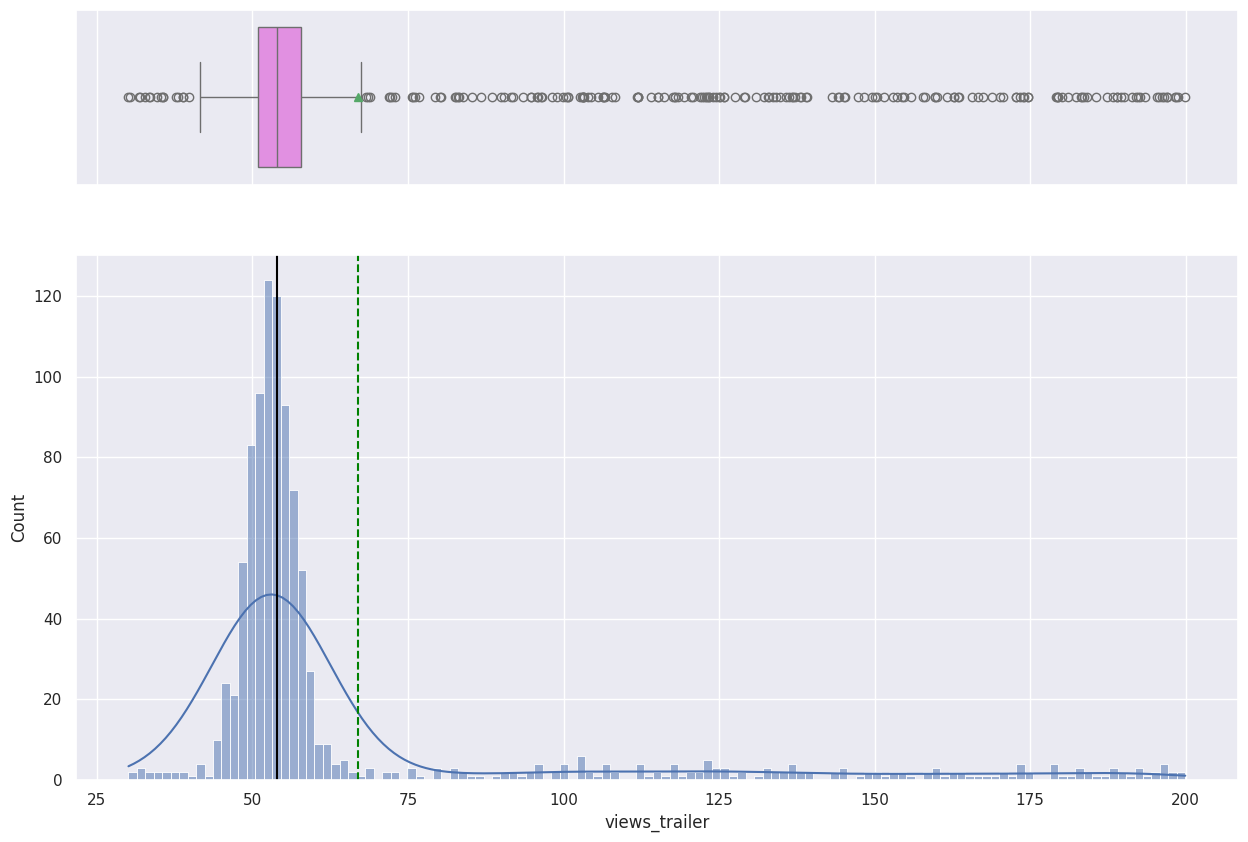

In [153]:
# trailer views histplot
histogram_boxplot(df, "views_trailer")

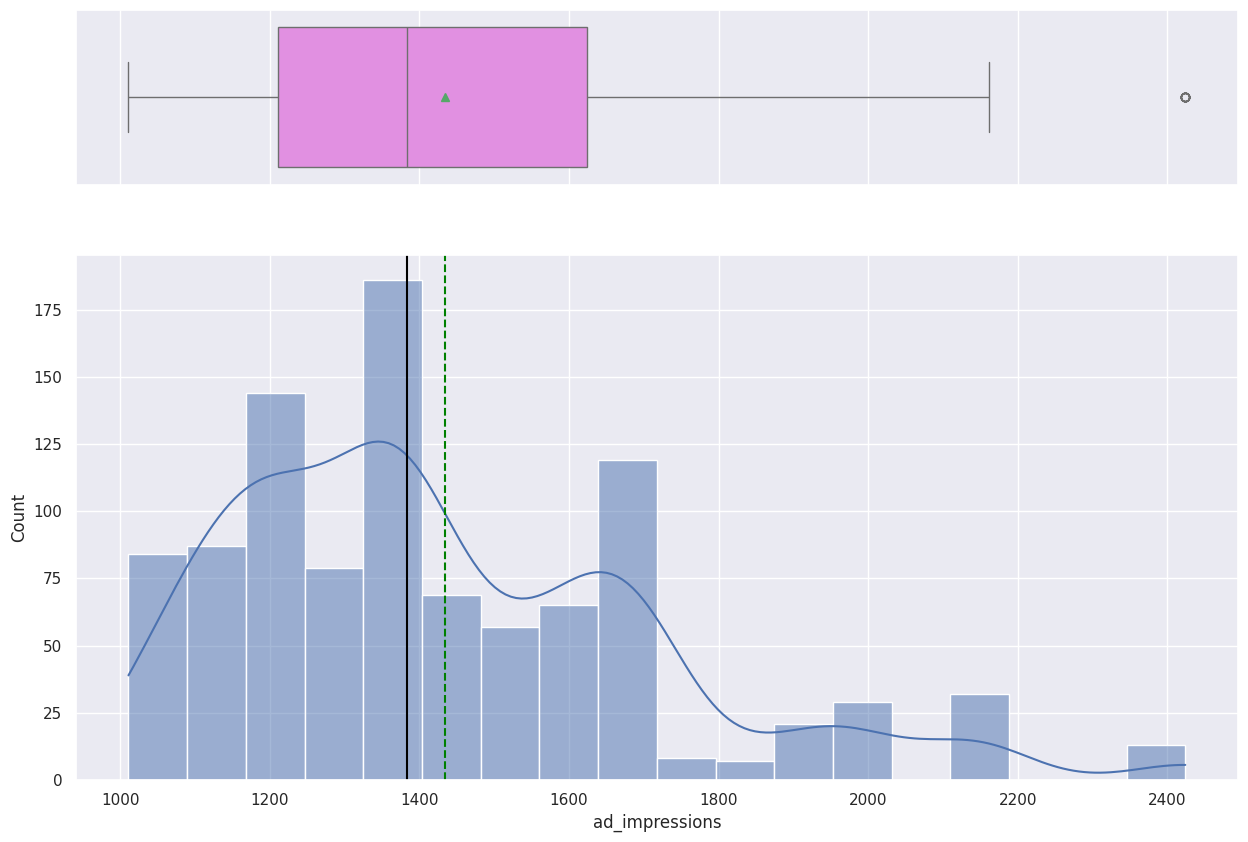

In [154]:
# Age histplot
histogram_boxplot(df, "ad_impressions")

- one outlier can be observed in the ad impression.
- It's not following a normal distribution.
- Mean ad impression is less than 1400.

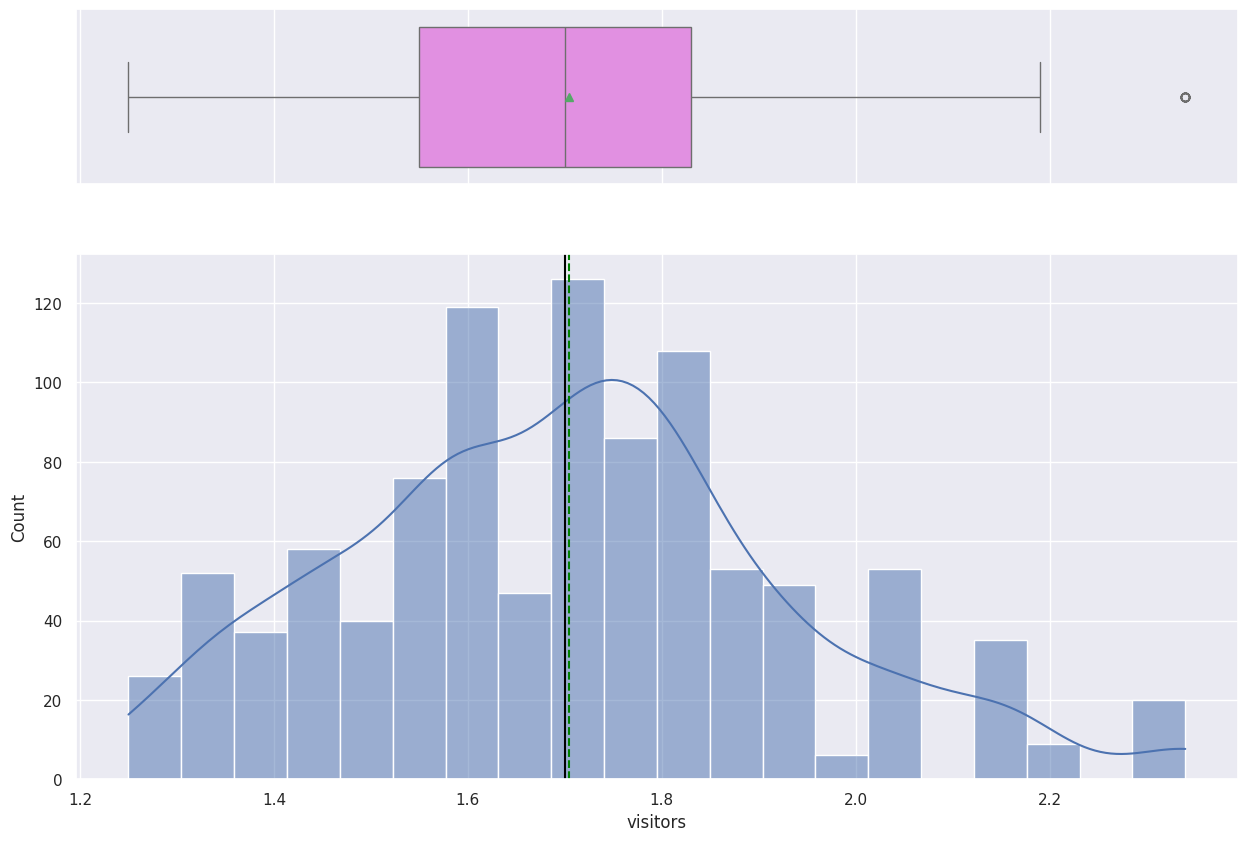

In [155]:
# Visitors histplot
histogram_boxplot(df, "visitors")

- Almost a normal distribution with only single outlier can be observed.
- Mean and median follows almost similar at 1.7 million visitors for previous week.

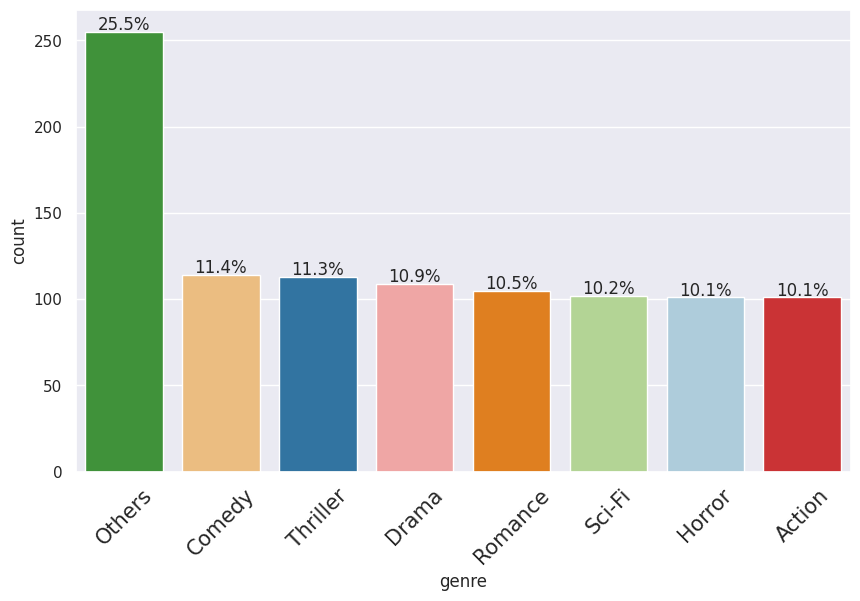

In [156]:
labeled_barplot(df, "genre", perc=True)

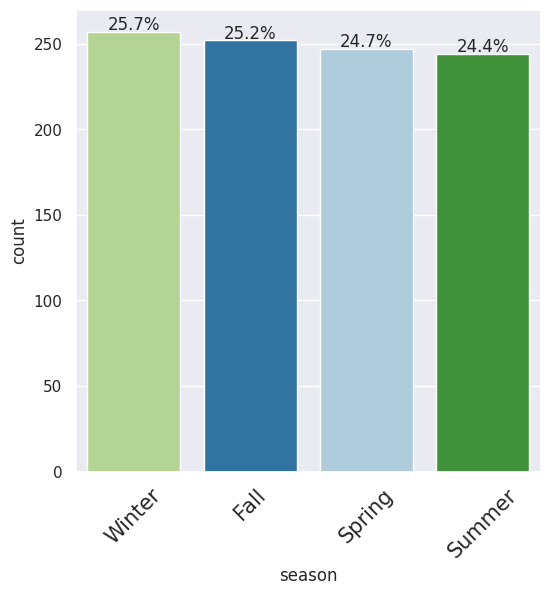

In [157]:
labeled_barplot(df, "season", perc=True)


- There are four season almost all of them contains one fourth of the data.

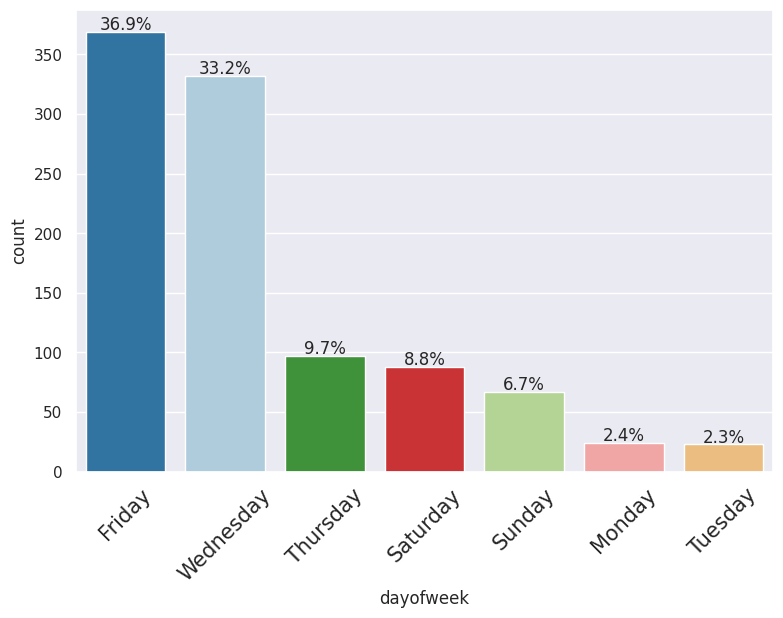

In [158]:
labeled_barplot(df, "dayofweek", perc=True);

-	Most of the content seems to be released on Friday followed by Wednesday.
-	Very few contents get released on Wednesday.


### Bivariate Analysis

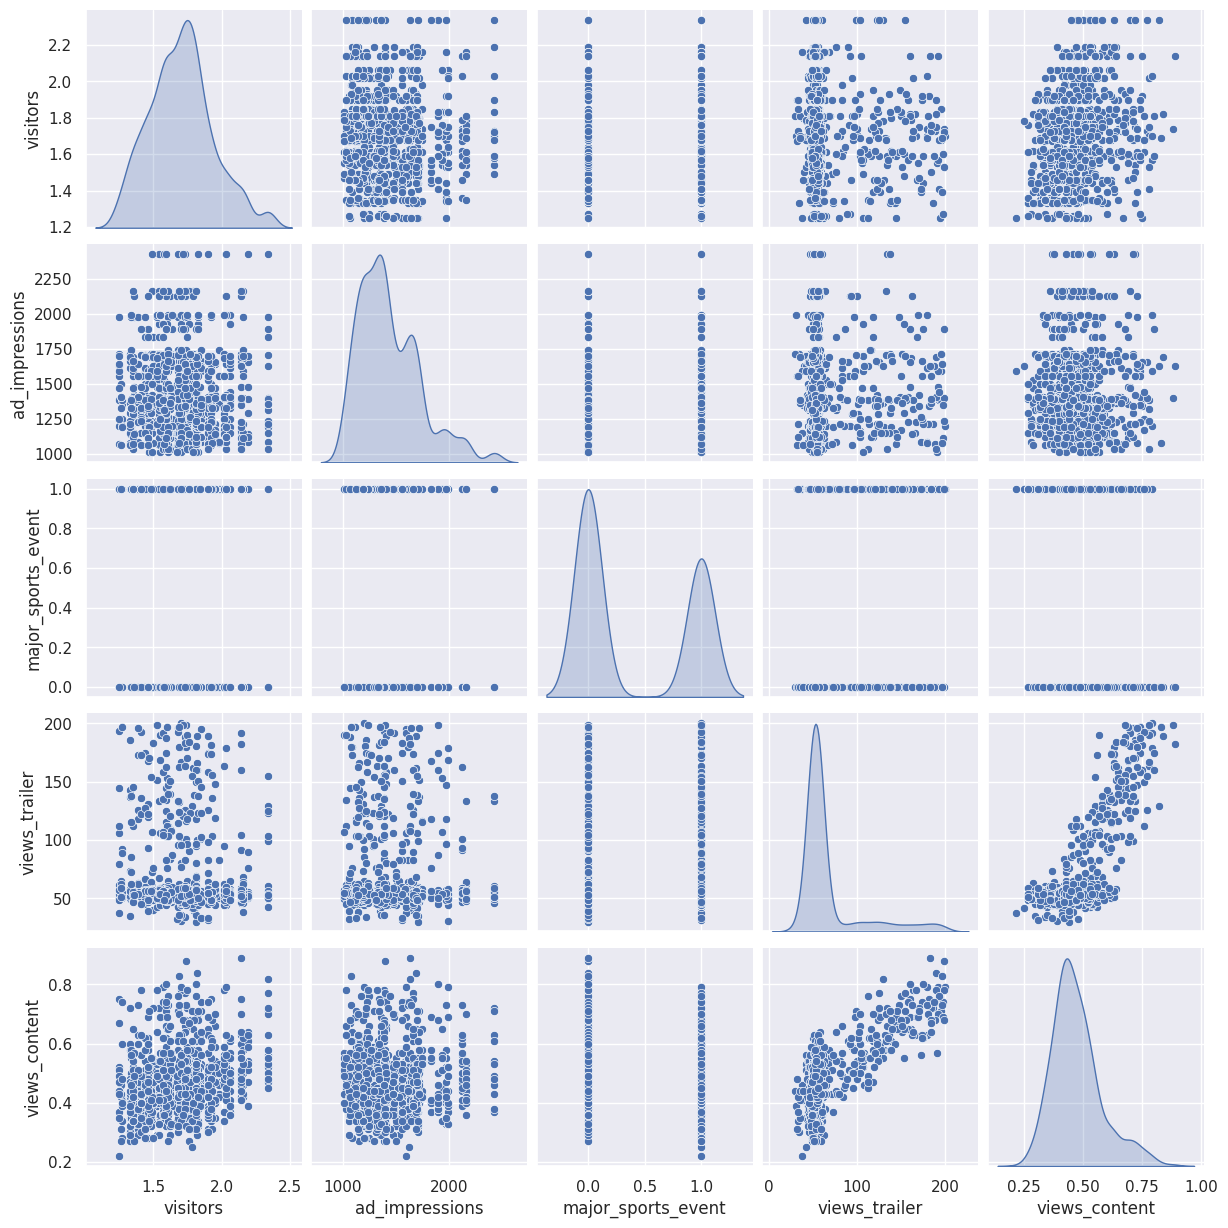

In [159]:
sns.pairplot(
    df, diag_kind="kde"
)  # to plot density curve instead of histogram on the diag

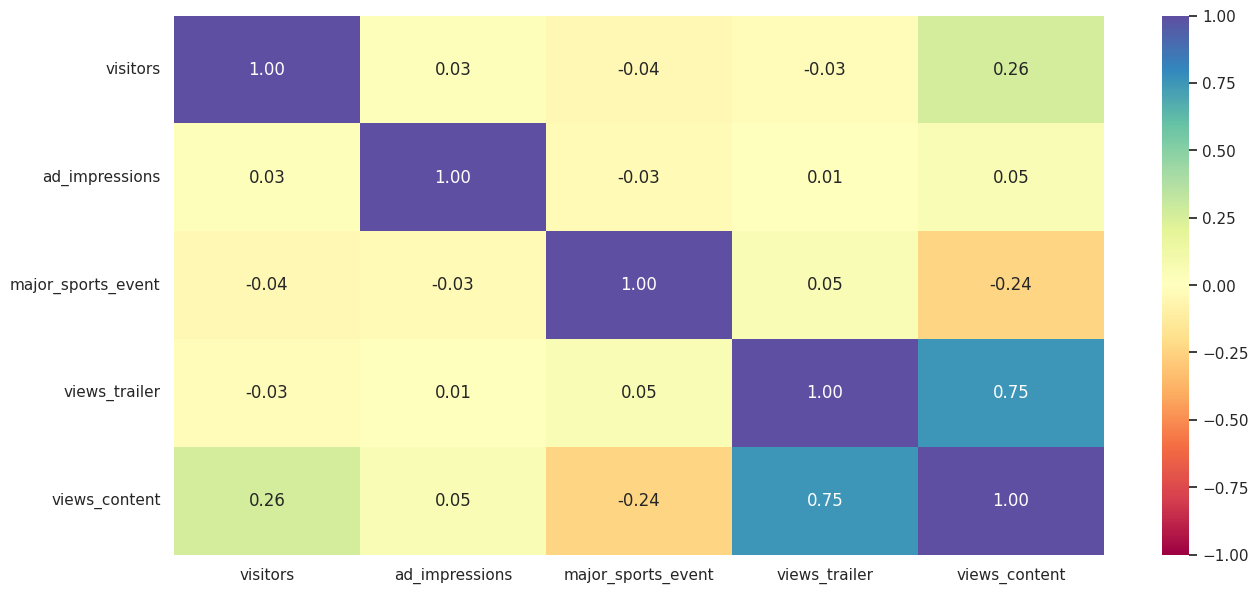

In [160]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(15, 7))
sns.heatmap(numeric_df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

-	Positive correlation can be observed between Views content and viws trailer.
-	A little negative correlation can be observed between major sprots event and content views.


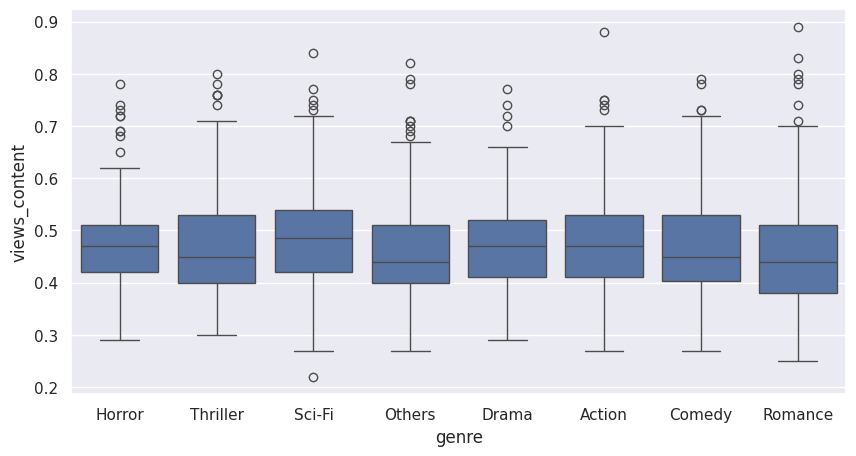

In [161]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="genre", y="views_content")
plt.show()

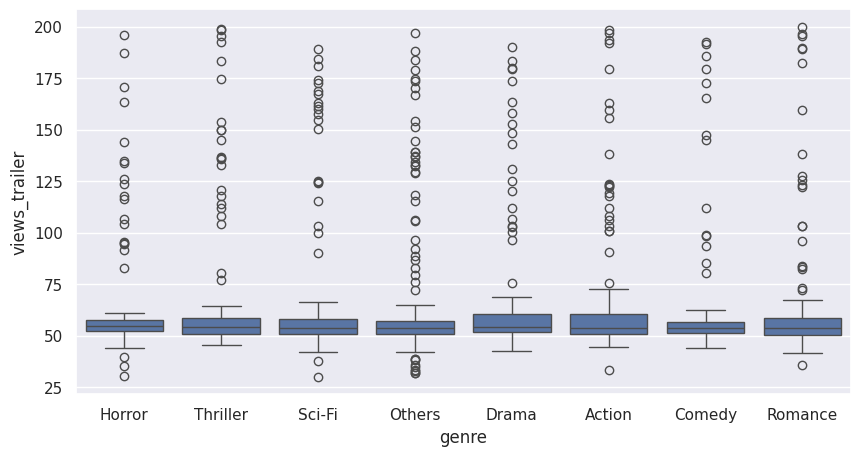

In [162]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="genre", y="views_trailer")
plt.show()

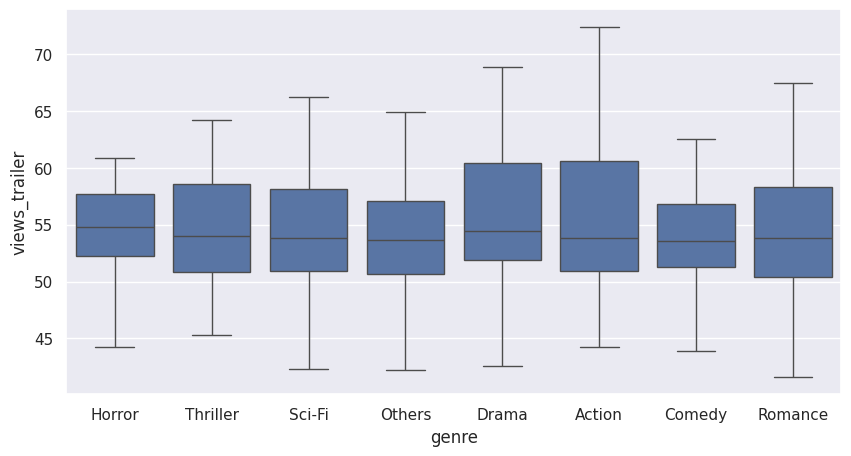

In [163]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="genre", y="views_trailer",showfliers = False)
plt.show()

- Outliers can be observed at the right.
- Seems to have almost mean of 53 - 55 million views in trailer for all the genre.

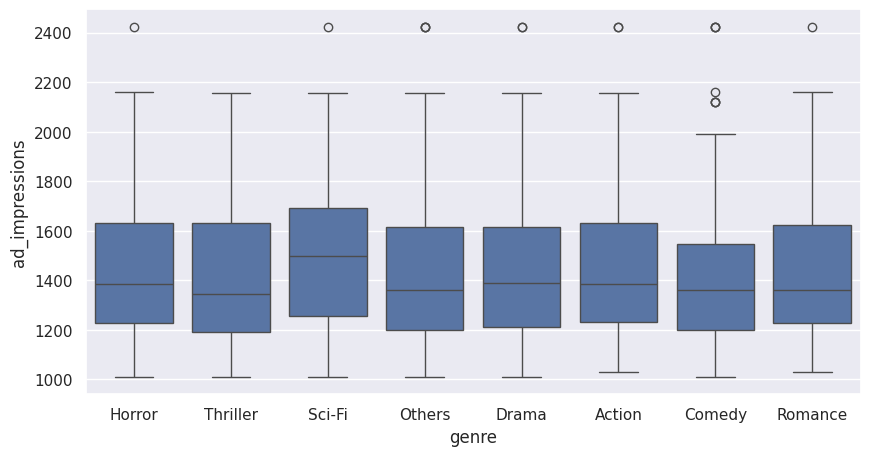

In [164]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="genre", y="ad_impressions") # Changed 'ad_impression' to 'ad_impressions'
plt.show()

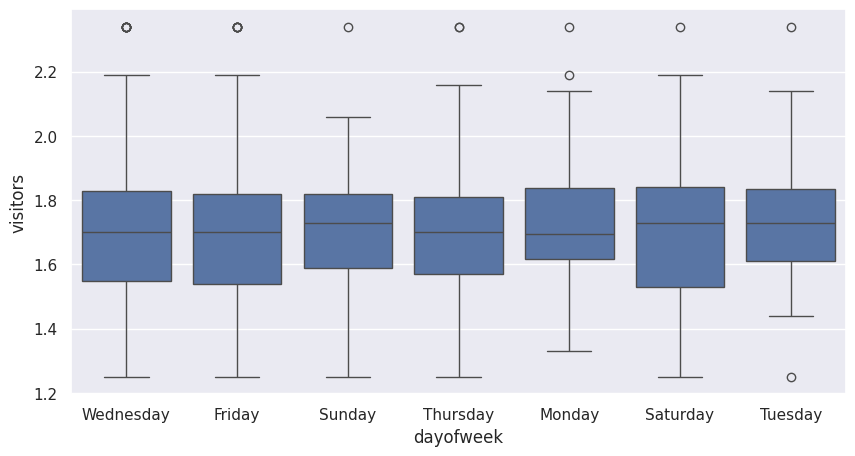

In [165]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="dayofweek", y="visitors")
plt.show()

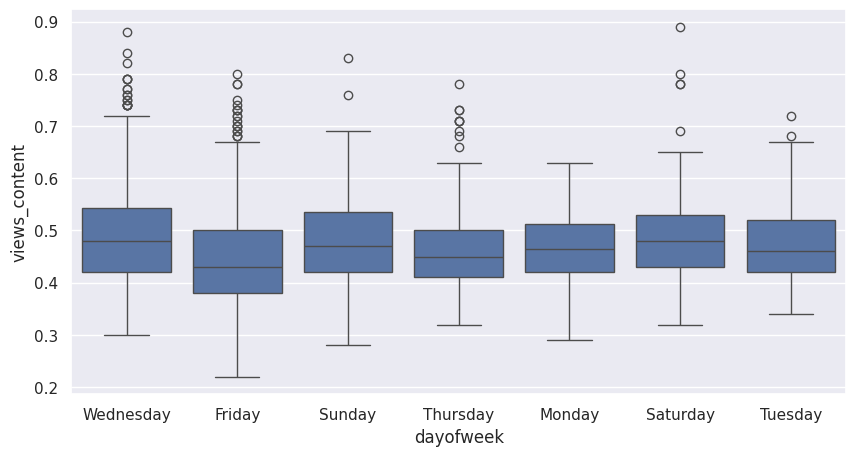

In [166]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="dayofweek", y="views_content")
plt.show()

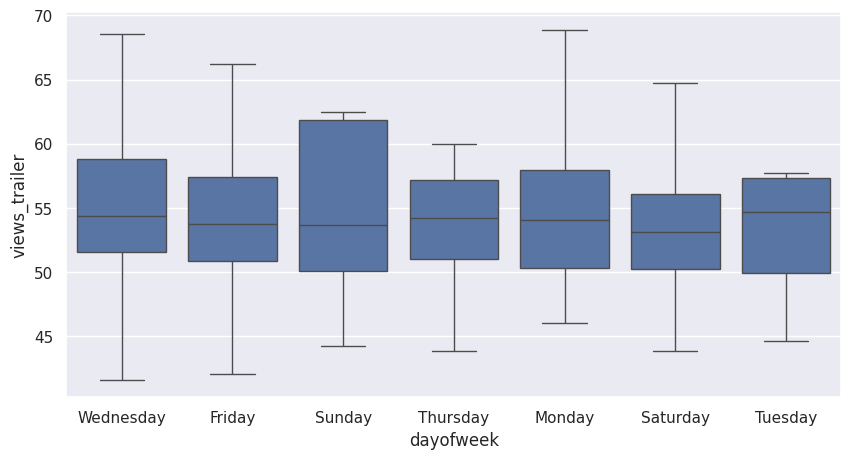

In [167]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="dayofweek", y="views_trailer",showfliers = False)
plt.show()

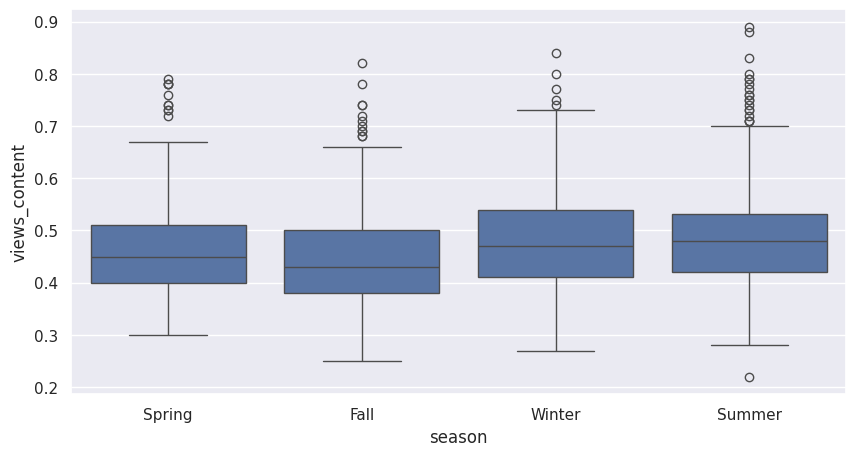

In [168]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="season", y="views_content")
plt.show()

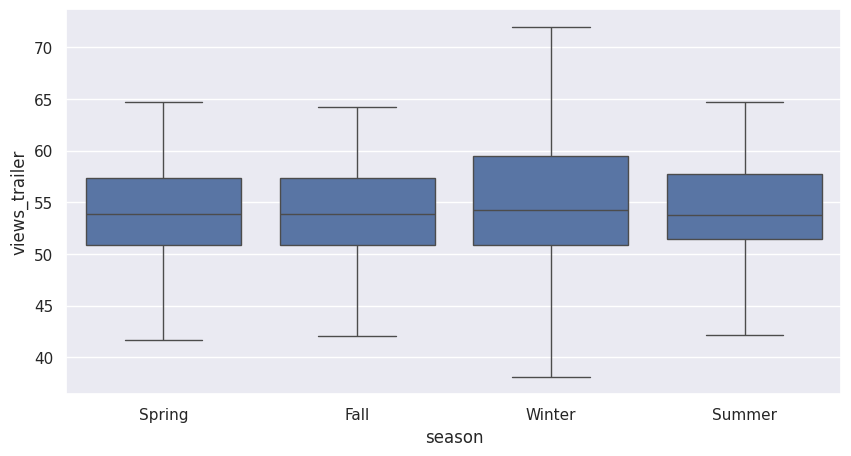

In [169]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="season", y="views_trailer", showfliers = False)
plt.show()

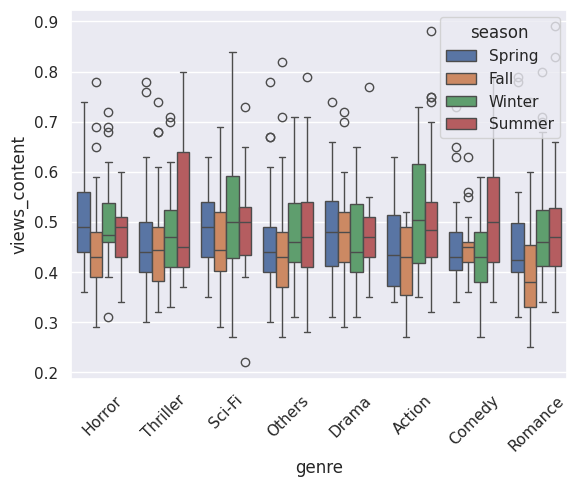

In [170]:
sns.boxplot(data=df, x='genre',y='views_content',hue='season')
plt.xticks(rotation=45);

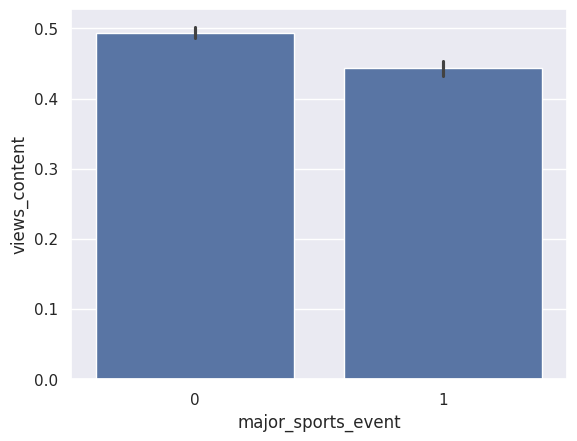

In [171]:
sns.barplot(data=df, x='major_sports_event',y='views_content');

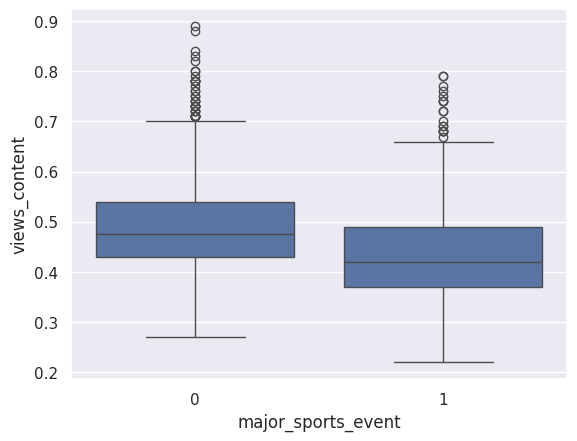

In [172]:
sns.boxplot(data=df, x='major_sports_event',y='views_content');

In [173]:
df.groupby('major_sports_event')['views_content'].mean()

,views_content
major_sports_event,
0,0.4938
1,0.4428


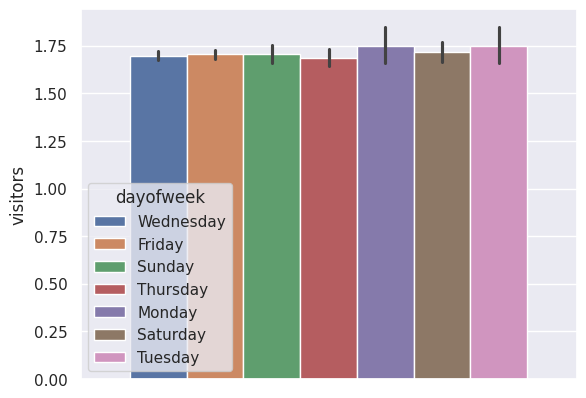

In [174]:
sns.barplot(data=df, hue='dayofweek', y='visitors');

**Let's check how trailer views can contribute to the content views.**

<Figure size 3000x1000 with 0 Axes>

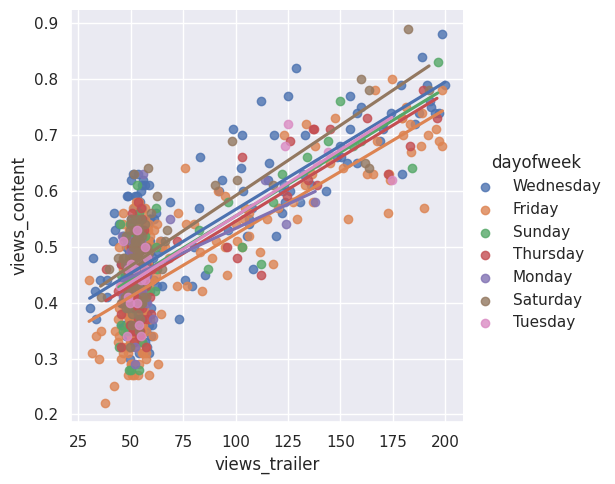

In [175]:
plt.figure(figsize = (30,10))
sns.lmplot(data=df, x='views_trailer',y='views_content',hue='dayofweek',ci=False);

##Data preprocessing
**For the column `major_sports_event`, replace the 1 values with '*yes*' and 0 values with '*no*'.**

In [176]:
df["major_sports_event"] = df["major_sports_event"].replace({1: "yes", 0: "no"})
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,no,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,yes,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,yes,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,yes,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,no,Sci-Fi,Sunday,Winter,55.83,0.46


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   object 
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


##Create Dummy Variables

In [178]:
# drop_first=True will drop one of the extra columns
df = pd.get_dummies(df, columns=df.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)
df.head()

,visitors,ad_impressions,views_trailer,views_content,major_sports_event_yes,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,...,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,56.70,0.51,False,False,False,True,False,False,...,False,False,False,False,False,False,True,True,False,False
1,1.46,1498.41,52.69,0.32,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,1.47,1079.19,48.74,0.39,True,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,1.85,1342.77,49.81,0.44,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.46,1498.41,55.83,0.46,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


##Split Data

In [179]:
# defining X and y variables
X = df.drop(["views_content"], axis=1)
y = df["views_content"]

print(X.head())
print(y.head())

   visitors  ad_impressions  views_trailer  major_sports_event_yes  \
0      1.67         1113.81          56.70                   False   
1      1.46         1498.41          52.69                    True   
2      1.47         1079.19          48.74                    True   
3      1.85         1342.77          49.81                    True   
4      1.46         1498.41          55.83                   False   

   genre_Comedy  genre_Drama  genre_Horror  genre_Others  genre_Romance  \
0         False        False          True         False          False   
1         False        False         False         False          False   
2         False        False         False         False          False   
3         False        False         False         False          False   
4         False        False         False         False          False   

   genre_Sci-Fi  genre_Thriller  dayofweek_Monday  dayofweek_Saturday  \
0         False           False             False      

In [180]:
# converting the input attributes into float type for modeling
X = X.astype(float)
X.head()

,visitors,ad_impressions,views_trailer,major_sports_event_yes,genre_Comedy,genre_Drama,genre_Horror,genre_Others,genre_Romance,genre_Sci-Fi,genre_Thriller,dayofweek_Monday,dayofweek_Saturday,dayofweek_Sunday,dayofweek_Thursday,dayofweek_Tuesday,dayofweek_Wednesday,season_Spring,season_Summer,season_Winter
0,1.67,1113.81,56.70,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.46,1498.41,52.69,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.47,1079.19,48.74,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.85,1342.77,49.81,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.46,1498.41,55.83,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [181]:
# splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [182]:
print("Number of rows in train data =", x_train.shape[0])
print("Number of rows in test data =", x_test.shape[0])

Number of rows in train data = 700
Number of rows in test data = 300


##Model Building - Linear Regression

In [183]:
x_train
olsmodel = sm.OLS(y_train, x_train).fit()


##Interpretation of Regression results

1. **Adjusted. R-squared**: It reflects the fit of the model.
    - Adjusted R-squared values generally range from 0 to 1, where a higher value generally indicates a better fit, assuming certain conditions are met.
    - In our case, the value for adj. R-squared is **0.785**, which is good.


2. ***const* coefficient**: It is the Y-intercept.
    - It means that if all the predictor variable coefficients are zero, then the expected output (i.e., Y) would be equal to the *const* coefficient.
    - In our case, the value for `const` coefficient is **0.0602**


3. **Coefficient of a predictor variable**: It represents the change in the output Y due to a change in the predictor variable (everything else held constant).
    - In our case, the coefficient of `Visitors` is **0.1295**.


### Interpretation of Coefficients

* The coefficients tell us how one unit change in X can affect y.

* The sign of the coefficient indicates if the relationship is positive or negative.

* In this data sert, for example, presence of sports event on same day occurs with a 0.0603 decrease in viewership, and increase in visitors by single person occurse with a 0.1295 increase in the content viewership.

* Earlier in the heat map, we observed that the relationship between major sports events and content viewership is negatively correlated (as sports events increase, content viewership decreases, and vice versa), while the relationship between the number of visitors and content viewership is positively correlated (as the number of visitors increases, content viewership also increases, and vice versa). Consequently, the signs of the coefficients align with these relationships, suggesting a low probability of multicollinearity in our data.

* Multicollinearity occurs when predictor variables in a regression model are correlated. This correlation is a problem because predictor variables should be independent.  If the collinearity between variables is high, we might not be able to trust the p-values to identify independent variables that are statistically significant.

* When we have multicollinearity in the linear model, the coefficients that the model suggests are unreliable.

### Interpretation of p-values (P > |t|)

* For each predictor variable there is a null hypothesis and alternate hypothesis.


    - Null hypothesis : Predictor variable is not significant
    - Alternate hypothesis : Predictor variable is significant


* (P > |t|) gives the p-value for each predictor variable to check the null hypothesis.

* If the level of significance is set to 5% (0.05), the p-values greater than 0.05 would indicate that the corresponding predictor variables are not significant.

* However, due to the presence of multicollinearity in our data, the p-values will also change.

* We need to ensure that there is no multicollinearity in order to interpret the p-values.

### How to check for Multicollinearity

* There are different ways of detecting (or testing) multicollinearity. One such way is Variation Inflation Factor.

* **Variance  Inflation  factor**:  Variance  inflation  factors  measure  the  inflation  in  the variances of the regression coefficients estimates due to collinearities that exist among the  predictors.  It  is  a  measure  of  how  much  the  variance  of  the  estimated  regression coefficient $\beta_k$ is "inflated" by  the  existence  of  correlation  among  the  predictor variables in the model.

* **General Rule of Thumb**:

    - If VIF is 1, then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence, the variance of $\beta_k$ is not inflated at all.
    - If VIF exceeds 5, we say there is moderate VIF, and if it is 10 or exceeding 10, it shows signs of high multi-collinearity.
    - The purpose of the analysis should dictate which threshold to use.
    

### Model Performance Check
Let's check the performance of the model using different metrics.

* We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.
* We will define a function to calculate MAPE and adjusted $R^2$.
    - The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.
    
* We will create a function which will print out all the above metrics in one go.

In [184]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [185]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.048903,0.038572,0.788404,0.782171,8.599372


In [186]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.050842,0.041065,0.764232,0.747331,9.051508


**Observations**

- The training $R^2$ is 0.79, so the model is not underfitting

- The train and test RMSE and MAE are comparable, so the model is not overfitting either

- MAE suggests that the model can predict anime ratings within a mean error of 0.40 on the test data

- MAPE of 9.03 on the test data means that we are able to predict within 9.03% of the anime ratings

We will be checking the following Linear Regression assumptions:

1. **No Multicollinearity**

2. **Linearity of variables**

3. **Independence of error terms**

4. **Normality of error terms**

5. **No Heteroscedasticity**

## TEST FOR MULTICOLLINEARITY
* Multicollinearity occurs when predictor variables in a regression model are correlated. This correlation is a problem because predictor variables should be independent. If the correlation between variables is high, it can cause problems when we fit the model and interpret the results. When we have multicollinearity in the linear model, the coefficients that the model suggests are unreliable.

* There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.

* **Variance  Inflation Factor (VIF)**:  Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors. It is a measure of how much the variance of the estimated regression coefficient $\beta_k$ is "inflated" by the existence of correlation among the predictor variables in the model.
    - If VIF is 1, then there is no correlation among the $k$th predictor and the remaining predictor variables, and hence, the variance of $\beta_k$ is not inflated at all.

* **General Rule of thumb**:
    - If VIF is between 1 and 5, then there is low multicollinearity.
    - If VIF is between 5 and 10, we say there is moderate multicollinearity.
    - If VIF is exceeding 10, it shows signs of high multicollinearity

In [187]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


def checking_vif(predictors):
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif

In [188]:
checking_vif(x_train)


,feature,VIF
0,visitors,24.180006
1,ad_impressions,20.119050
2,views_trailer,4.724520
3,major_sports_event_yes,1.704579
4,genre_Comedy,1.985329
5,genre_Drama,2.010778
6,genre_Horror,1.949398
7,genre_Others,2.952964
8,genre_Romance,1.799544
9,genre_Sci-Fi,1.954927


In [189]:
# drop the genre_Others and check if the r-sq shows significant variation
x_train2 = x_train.drop(["genre_Others"], axis=1)
olsmod_1 = sm.OLS(y_train, x_train2)
olsres_1 = olsmod_1.fit()
print(
    "R-squared:",
    np.round(olsres_1.rsquared, 3),
    "\nAdjusted R-squared:",
    np.round(olsres_1.rsquared_adj, 3),
)

R-squared: 0.99 
Adjusted R-squared: 0.99


- On dropping 'genre_Others', adj. R-squared increased by 0.001 and R-Square decreased by 0.001

In [190]:
x_train = x_train.drop(["genre_Others"], axis=1)

In [191]:
olsmod_2 = sm.OLS(y_train, x_train)
olsres_2 = olsmod_2.fit()
print(olsres_2.summary())

                                 OLS Regression Results                                
Dep. Variable:          views_content   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                              3491.
Date:                Sun, 15 Dec 2024   Prob (F-statistic):                        0.00
Time:                        16:44:56   Log-Likelihood:                          1116.9
No. Observations:                 700   AIC:                                     -2196.
Df Residuals:                     681   BIC:                                     -2109.
Df Model:                          19                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

**Let's check if multicollinearity is still present in the data.**

In [192]:
# let's check the VIF of the predictors
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_series2 = pd.Series(
    [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
    index=x_train.columns,
)
print("VIF values: \n\n{}\n".format(vif_series2))

VIF values: 

visitors                  22.169287
ad_impressions            19.454428
views_trailer              4.722966
major_sports_event_yes     1.702916
genre_Comedy               1.349769
genre_Drama                1.371022
genre_Horror               1.336181
genre_Romance              1.284729
genre_Sci-Fi               1.345550
genre_Thriller             1.349185
dayofweek_Monday           1.091263
dayofweek_Saturday         1.262503
dayofweek_Sunday           1.235835
dayofweek_Thursday         1.286360
dayofweek_Tuesday          1.079511
dayofweek_Wednesday        1.988232
season_Spring              1.970946
season_Summer              1.983413
season_Winter              2.106783
dtype: float64



- All the variables has VIF less than 2.
- We have dealt with multicollinearity in the data
- Let's rebuild the model using the updated set of predictors variables

**Now that we do not have multicollinearity in our data, the p-values of the coefficients have become reliable and we can remove the non-significant predictor variables all togather having p value > 0.05**

In [193]:
olsmod_2 = sm.OLS(y_train, x_train).fit()
print(olsmod_2.summary())

                                 OLS Regression Results                                
Dep. Variable:          views_content   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                              3491.
Date:                Sun, 15 Dec 2024   Prob (F-statistic):                        0.00
Time:                        16:44:56   Log-Likelihood:                          1116.9
No. Observations:                 700   AIC:                                     -2196.
Df Residuals:                     681   BIC:                                     -2109.
Df Model:                          19                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [194]:
# initial list of columns
predictors = x_train.copy()
cols = predictors.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = predictors[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['visitors', 'ad_impressions', 'views_trailer', 'major_sports_event_yes', 'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday', 'dayofweek_Thursday', 'dayofweek_Wednesday', 'season_Spring', 'season_Summer', 'season_Winter']


In [195]:
x_train2 = x_train[selected_features]
x_test2 = x_test[selected_features]

In [196]:
olsmod_3 = sm.OLS(y_train, x_train2).fit()
print(olsmod_3.summary())

                                 OLS Regression Results                                
Dep. Variable:          views_content   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                              5506.
Date:                Sun, 15 Dec 2024   Prob (F-statistic):                        0.00
Time:                        16:44:56   Log-Likelihood:                          1112.0
No. Observations:                 700   AIC:                                     -2200.
Df Residuals:                     688   BIC:                                     -2145.
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [197]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmod3_train_perf = model_performance_regression(olsmod_3, x_train2, y_train)
olsmod3_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.049414,0.038814,0.783953,0.78018,8.641302


Training Performance

In [198]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmod3_test_perf = model_performance_regression(olsmod_3, x_test2, y_test)
olsmod3_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051541,0.041869,0.757708,0.747578,9.262476


## Assumptions of Linear Regression

These assumptions are essential conditions that should be met before we draw inferences regarding the model estimates or use the model to make a prediction.

For Linear Regression, we need to check if the following assumptions hold:-

1. Linearity
2. Independence
3. Homoscedasticity
4. Normality of error terms
5. No strong Multicollinearity

In [199]:
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train.values.flatten()  # actual values
df_pred["Fitted Values"] = olsmod_3.fittedvalues.values  # predicted values
df_pred["Residuals"] = olsmod_3.resid.values  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
0,0.40,0.451458,-0.051458
1,0.70,0.690918,0.009082
2,0.42,0.422708,-0.002708
3,0.55,0.548172,0.001828
4,0.59,0.554912,0.035088


### TEST FOR LINEARITY AND INDEPENDENCE

**Why the test?**
* Linearity describes a straight-line relationship between two variables, predictor variables must have a linear relation with the dependent variable.

**How to check linearity?**

* Make a plot of fitted values vs residuals. If they don't follow any pattern (the curve is a straight line), then we say the model is linear otherwise model is showing signs of non-linearity.

**How to fix if this assumption is not followed?**

* We can try different transformations.

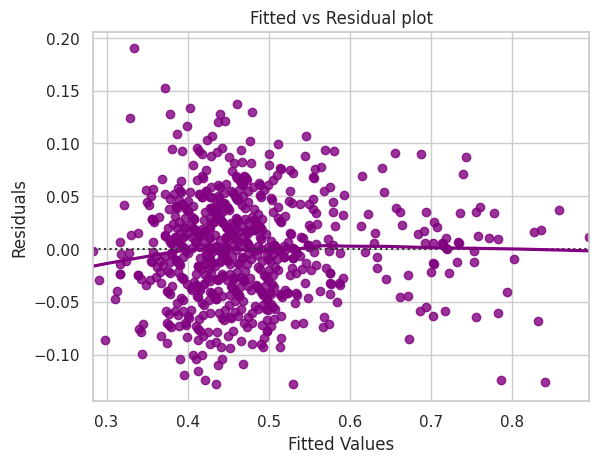

In [200]:
# let us plot the fitted values vs residuals
sns.set_style("whitegrid")
sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

### TEST FOR NORMALITY

**What is the test?**

* Error terms/residuals should be normally distributed.

* If the error terms are not normally distributed, confidence intervals may become too wide or narrow. Once confidence interval becomes unstable, it leads to difficulty in estimating coefficients based on minimization of least squares.

**What does non-normality indicate?**

* It suggests that there are a few unusual data points which must be studied closely to make a better model.

**How to check the Normality?**

* It can be checked via QQ Plot - residuals following normal distribution will make a straight line plot, otherwise not.

* Another test to check for normality is the Shapiro-Wilk test.

**How to Make residuals normal?**

* We can apply transformations like log, exponential, arcsinh, etc as per our data.

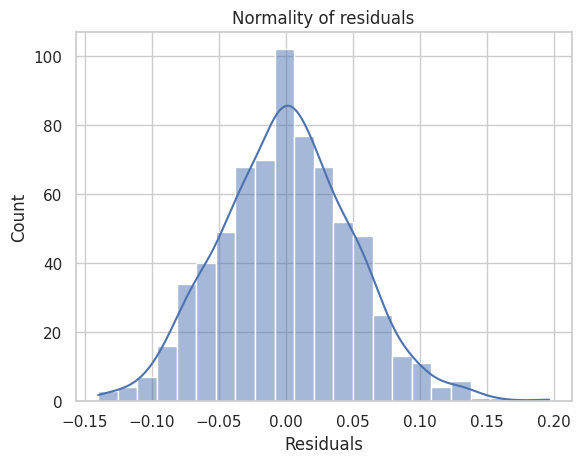

In [201]:
sns.histplot(df_pred["Residuals"], kde=True)
plt.title("Normality of residuals")
plt.show()

**The Q-Q plot of residuals can be used to visually check the normality assumption. The normal probability plot of residuals should approximately follow a straight line.**

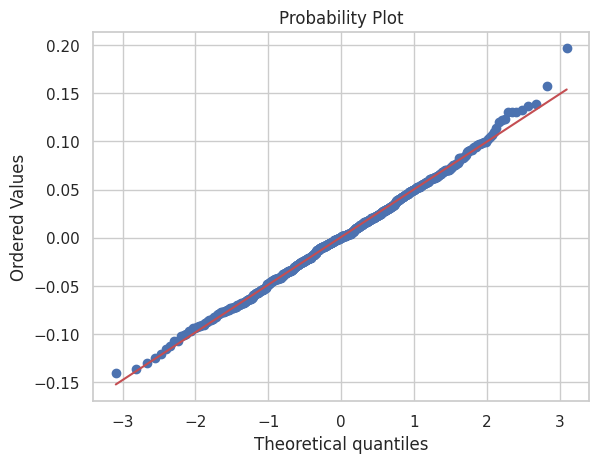

In [202]:
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

* Most of the points are lying on the straight line in QQ plot

In [203]:
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=0.9971849581868388, pvalue=0.2711632085854436)

### TEST FOR HOMOSCEDASTICITY

* **Homoscedacity** - If the variance of the residuals are symmetrically distributed across the regression line , then the data is said to homoscedastic.

* **Heteroscedacity** - If the variance is unequal for the residuals across the regression line, then the data is said to be heteroscedastic. In this case the residuals can form an arrow shape or any other non symmetrical shape.

**Why the test?**

* The presence of non-constant variance in the error terms results in heteroscedasticity. Generally, non-constant variance arises in presence of outliers.

**How to check if model has Heteroscedasticity?**

* Can use the goldfeldquandt test. If we get p-value > 0.05 we can say that the residuals are homoscedastic, otherwise they are heteroscedastic.

**How to deal with Heteroscedasticity?**

* Can be fixed via adding other important features or making transformations.

```
The null and alternate hypotheses of the goldfeldquandt test are as follows:

Null hypothesis : Residuals are homoscedastic
Alternate hypothesis : Residuals have hetroscedasticity
```

In [204]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

In [205]:
name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train2)
lzip(name, test)

[('F statistic', 1.140850904518466), ('p-value', 0.11314163225616655)]

## Predictions on test data

In [206]:
# predictions on the test set
pred = olsmod_3.predict(x_test2)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
983,0.43,0.430924
194,0.51,0.491955
314,0.48,0.418631
429,0.41,0.505562
267,0.41,0.488199
746,0.68,0.688240
186,0.62,0.585969
964,0.48,0.499289
676,0.42,0.487114
320,0.58,0.567771


## Final Model

**All the assumptions of linear regression are now satisfied. Let's check the summary of our final model (olsres_11).**

In [207]:
x_train_final = x_train2.copy()
x_test_final = x_test2.copy()

In [208]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                                 OLS Regression Results                                
Dep. Variable:          views_content   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                              5506.
Date:                Sun, 15 Dec 2024   Prob (F-statistic):                        0.00
Time:                        16:44:58   Log-Likelihood:                          1112.0
No. Observations:                 700   AIC:                                     -2200.
Df Residuals:                     688   BIC:                                     -2145.
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [209]:
# checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(
    olsmodel_final, x_train_final, y_train
)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.049414,0.038814,0.783953,0.78018,8.641302


In [210]:
# checking model performance on test set (seen 30% data)
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(
    olsmodel_final, x_test_final, y_test
)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.051541,0.041869,0.757708,0.747578,9.262476


### Conclusions and Recommendations


- The model's R-squared value is approximately 0.79, and the adjusted R-squared is 0.786, indicating that the model can explain about 79% of the variance in the data. This is quite satisfactory.

    - This suggests that the model is suitable for both prediction and inference purposes.

- A major sports event will lead to a 0.0604 unit decrease in content viewership, assuming all other variables remain constant.

    - To improve content viewership, it is recommended to avoid releasing content on days when major sports events are happening.

- An increase of one unit in the 'visitors' variable results in a 0.1291 unit increase in content viewership, with all other variables held constant.

    - The client should provide more detailed information to identify the reasons behind increases in viewership.

- An increase of one unit in trailer viewers will result in a 0.0023 unit increase in content viewership, all other variables held constant.

- Releasing content on specific days of the week will increase viewership: Saturday (0.0583 units), Wednesday (0.0478 units), Sunday (0.0357 units), Monday (0.0334 units), Tuesday (0.0242 units), and Thursday (0.0168 units), with all other variables held constant.

    - Therefore, releasing content on Saturdays and Wednesdays will boost viewership, provided no major sports events occur on those days.

- The summer season can result in a 0.0438 unit increase in content viewership, with all other variables held constant.

    - Releasing content during the summer season can enhance viewership.



## Predictions

In [211]:
# let's check the model parameters
olsmod_3.params

,0
visitors,0.153631
ad_impressions,0.000017
views_trailer,0.002376
major_sports_event_yes,-0.058108
dayofweek_Monday,0.033747
dayofweek_Saturday,0.057602
dayofweek_Sunday,0.034887
dayofweek_Thursday,0.017989
dayofweek_Wednesday,0.048274
season_Spring,0.026963


In [212]:
# Let us write the equation of linear regression
Equation = "Content Views ="
print(Equation, end=" ")
for i in range(len(x_train2.columns)):
    if i == 0:
        print(olsmod_3.params[i], "+", end=" ")
    elif i != len(x_train2.columns) - 1:
        print(
            olsmod_3.params[i],
            "* (",
            x_train2.columns[i],
            ")",
            "+",
            end="  ",
        )
    else:
        print(olsmod_3.params[i], "* (", x_train2.columns[i], ")")

Content Views = 0.15363110847222627 + 1.748933207435469e-05 * ( ad_impressions ) +  0.002375803980925438 * ( views_trailer ) +  -0.058107991752532 * ( major_sports_event_yes ) +  0.03374730351542127 * ( dayofweek_Monday ) +  0.05760244250386098 * ( dayofweek_Saturday ) +  0.03488746430290374 * ( dayofweek_Sunday ) +  0.017989102409065733 * ( dayofweek_Thursday ) +  0.04827377255005637 * ( dayofweek_Wednesday ) +  0.026963378073691317 * ( season_Spring ) +  0.04676791695482065 * ( season_Summer ) +  0.029449310510126767 * ( season_Winter )


<ipython-input-212-838bbeffe16e>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod_3.params[i], "+", end=" ")
<ipython-input-212-838bbeffe16e>:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  olsmod_3.params[i],
<ipython-input-212-838bbeffe16e>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod_3.params[i], "* (", x_train2.columns[i], ")")


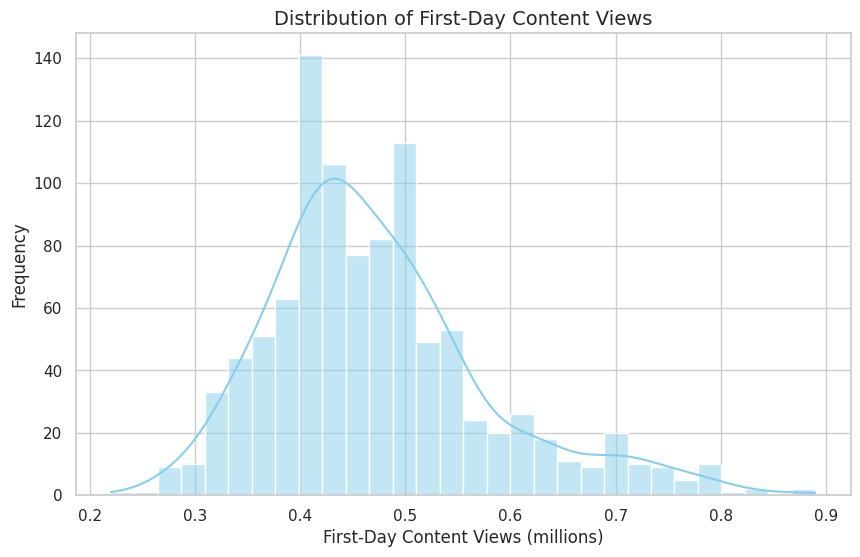

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is the DataFrame containing the data
# Replace 'ott_data' with 'df'
plt.figure(figsize=(10, 6))
sns.histplot(df['views_content'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of First-Day Content Views', fontsize=14)
plt.xlabel('First-Day Content Views (millions)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

<ipython-input-217-fd7160a29c40>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='genre', palette='viridis', order=df['genre'].value_counts().index)


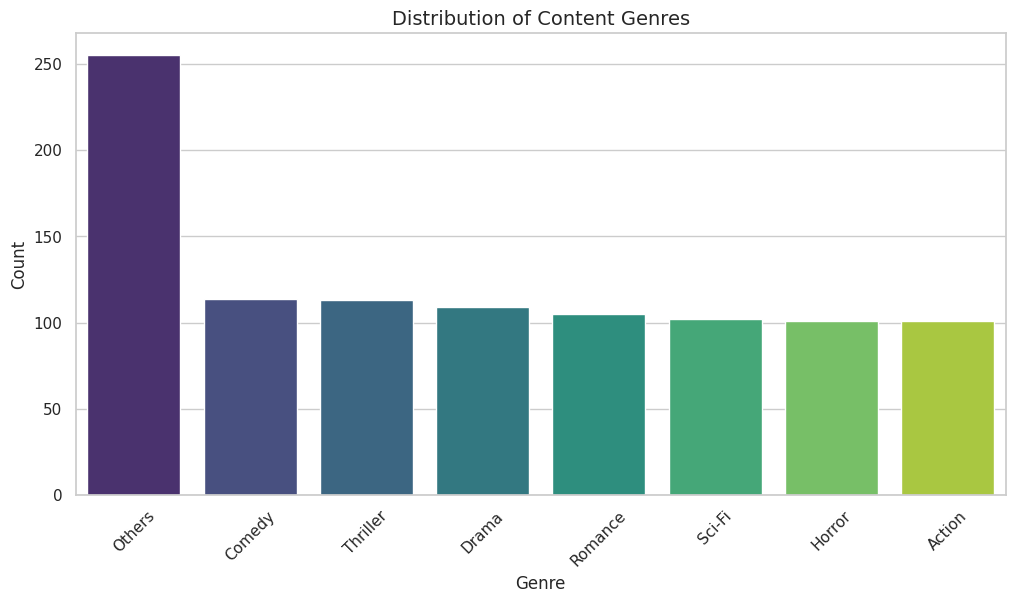

In [217]:
# Plot the distribution of genres
plt.figure(figsize=(12, 6))
# Replace 'ott_data' with 'df'
sns.countplot(data=df, x='genre', palette='viridis', order=df['genre'].value_counts().index)
plt.title('Distribution of Content Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-219-99ebba07a6c6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='dayofweek', y='views_content', palette='Set2',


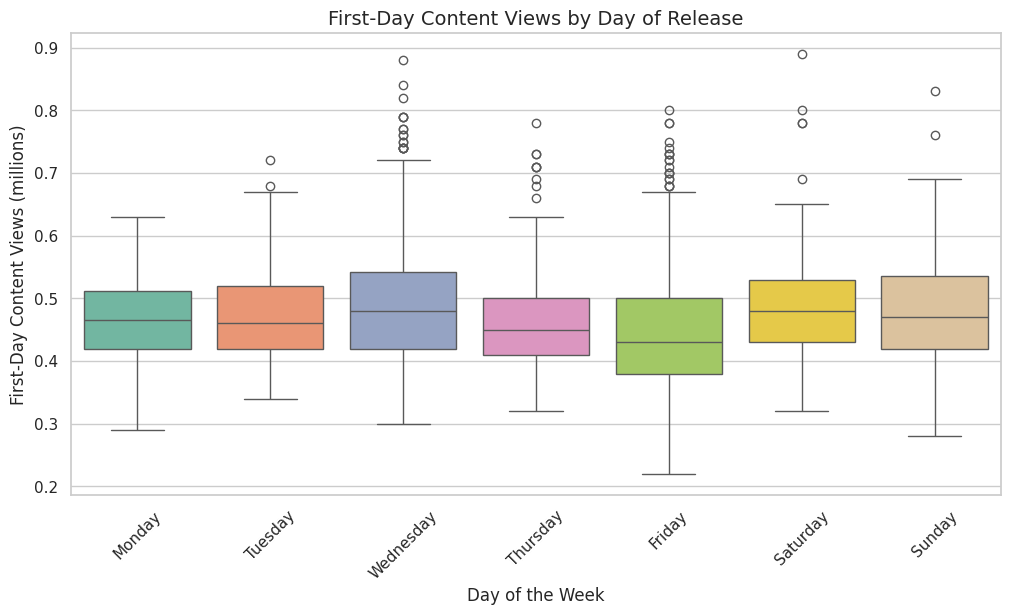

In [219]:
# Boxplot for viewership by day of the week
plt.figure(figsize=(12, 6))
# Replace 'ott_data' with 'df' to use the correct DataFrame
sns.boxplot(data=df, x='dayofweek', y='views_content', palette='Set2',
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('First-Day Content Views by Day of Release', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('First-Day Content Views (millions)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

<ipython-input-221-f23d874d98e0>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y='views_content', palette='coolwarm', # Changed 'ott_data' to 'df'


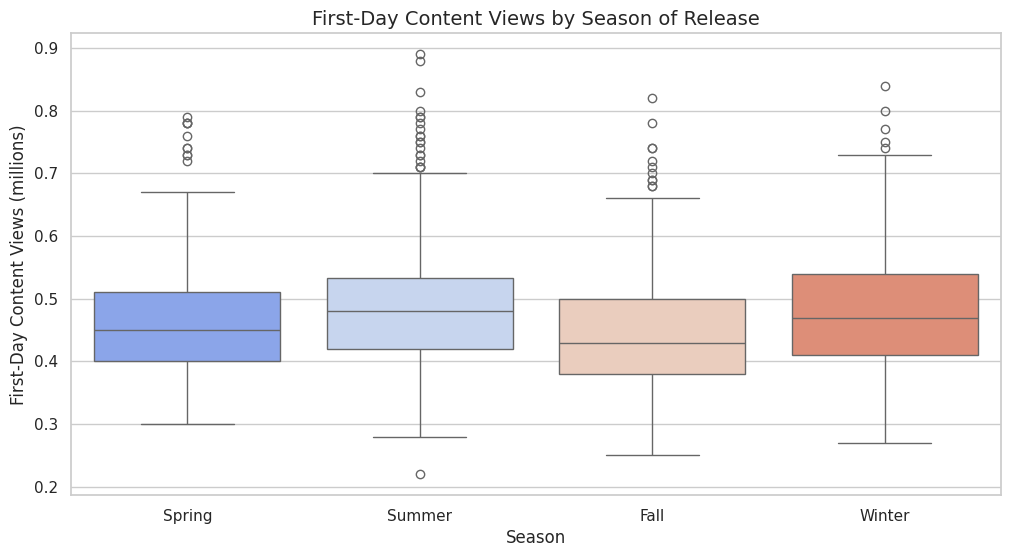

In [221]:
# Boxplot for viewership by season
plt.figure(figsize=(12, 6))
# Replace 'ott_data' with 'df' to use the correct DataFrame
sns.boxplot(data=df, x='season', y='views_content', palette='coolwarm', # Changed 'ott_data' to 'df'
            order=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('First-Day Content Views by Season of Release', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('First-Day Content Views (millions)', fontsize=12)
plt.show()

Correlation between trailer views and content views: 0.75


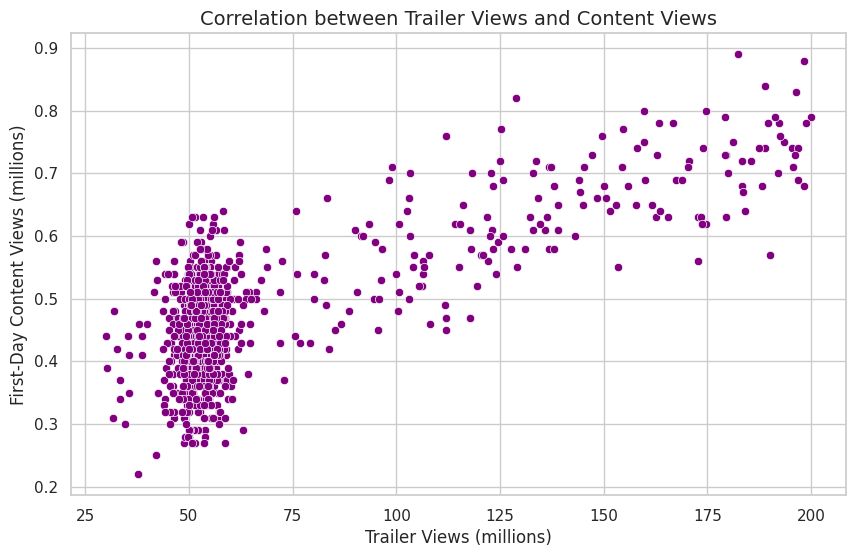

In [223]:
# Calculate the correlation coefficient
correlation = df['views_trailer'].corr(df['views_content']) # Changed 'ott_data' to 'df'
print(f"Correlation between trailer views and content views: {correlation:.2f}")

# Scatter plot for trailer views vs. content views
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='views_trailer', y='views_content', color='purple') # Changed 'ott_data' to 'df'
plt.title('Correlation between Trailer Views and Content Views', fontsize=14)
plt.xlabel('Trailer Views (millions)', fontsize=12)
plt.ylabel('First-Day Content Views (millions)', fontsize=12)
plt.show()